1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
session_order = pd.read_parquet('../../data/processed/session_order.parquet')
order_product = pd.read_parquet('../../data/processed/order_product.parquet')
order_refund = pd.read_parquet('../../data/processed/order_refund.parquet')

In [3]:
session_order.head()

,website_session_id,created_at_x,user_id_x,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,order_id,created_at_y,user_id_y,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaT,NaN,NaN,NaN,NaN,NaN
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaT,NaN,NaN,NaN,NaN,NaN
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [4]:
order_product.head()

,order_id,created_at_x,website_session_id,user_id,primary_product_id,items_purchased,price_usd_x,cogs_usd_x,order_item_id,created_at_y,product_id,is_primary_item,price_usd_y,cogs_usd_y,created_at,product_name
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,1,2012-03-19 10:42:46,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2,2012-03-19 19:27:37,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,3,2012-03-20 06:44:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,4,2012-03-20 09:41:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,5,2012-03-20 11:28:15,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy


In [5]:
order_refund.head()

,order_item_id,created_at_x,order_id_x,product_id,is_primary_item,price_usd,cogs_usd,order_item_refund_id,created_at_y,order_id_y,refund_amount_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,NaN,NaT,NaN,NaN
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,NaN,NaT,NaN,NaN
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,NaN,NaT,NaN,NaN
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,NaN,NaT,NaN,NaN
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,NaN,NaT,NaN,NaN


2. Monthly Traffic Trend

In [6]:
session_order['year_month'] = (
    session_order['created_at_x']
    .dt.to_period('M')
)

In [11]:
monthly_sessions = (session_order.groupby('year_month')['website_session_id'].nunique())

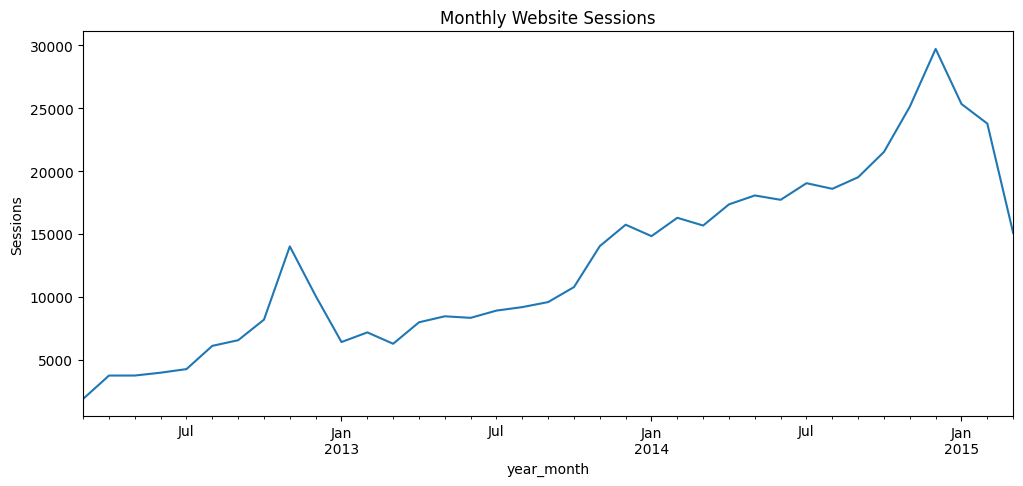

In [12]:
monthly_sessions.plot(figsize=(12,5))
plt.title('Monthly Website Sessions')
plt.ylabel('Sessions')
plt.show()

3. Traffic Source Distribution

In [13]:
source_dist = (session_order['utm_source'].fillna('organic/direct').value_counts())

In [15]:
print(source_dist)

utm_source
gsearch           316035
organic/direct     83328
bsearch            62823
socialbook         10685
Name: count, dtype: int64


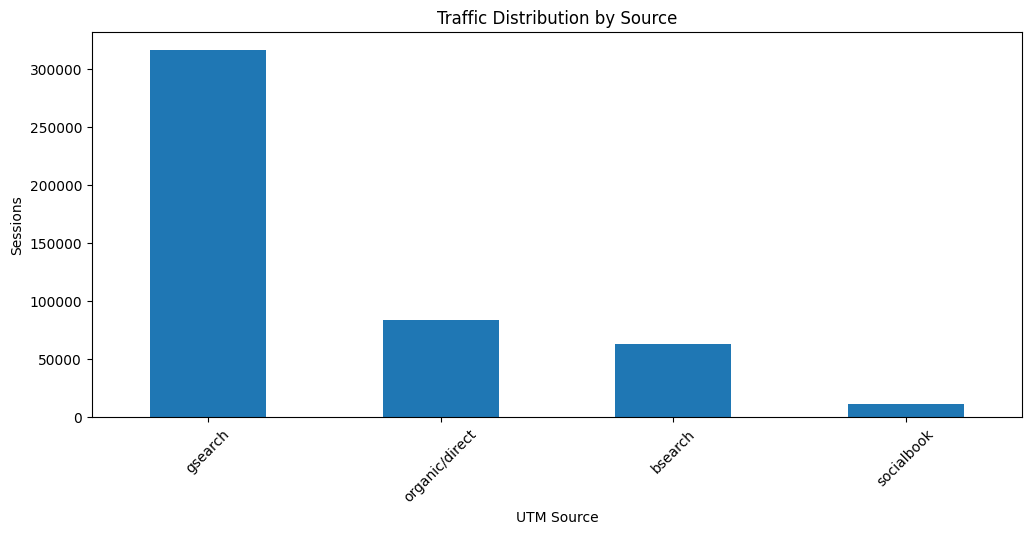

In [24]:
source_dist.plot(kind='bar', figsize=(12,5))
plt.title('Traffic Distribution by Source')
plt.xlabel('UTM Source')
plt.ylabel('Sessions')
plt.xticks(rotation=45)
plt.show()

4. Divide Distribution

In [25]:
device_dist = (session_order['device_type'].fillna('unknown').value_counts())

In [26]:
device_dist

device_type
desktop    327027
mobile     145844
Name: count, dtype: int64

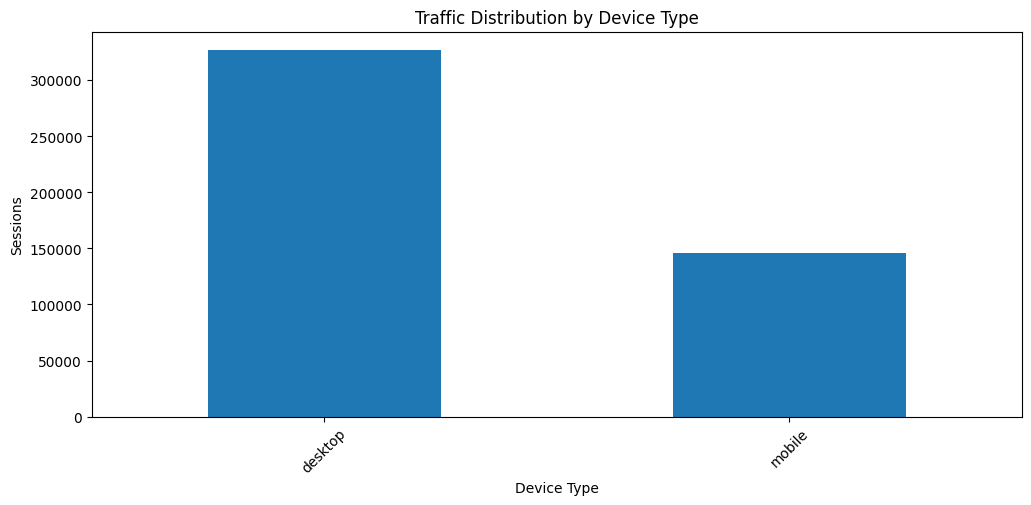

In [28]:
device_dist.plot(kind='bar', figsize=(12,5))
plt.title('Traffic Distribution by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Sessions')
plt.xticks(rotation=45)
plt.show()

5. Campaign Distribution

In [29]:
campaign_dist = (session_order['utm_campaign'].fillna('organic/direct').value_counts())

In [30]:
campaign_dist

utm_campaign
nonbrand            337615
organic/direct       83328
brand                41243
desktop_targeted      5590
pilot                 5095
Name: count, dtype: int64

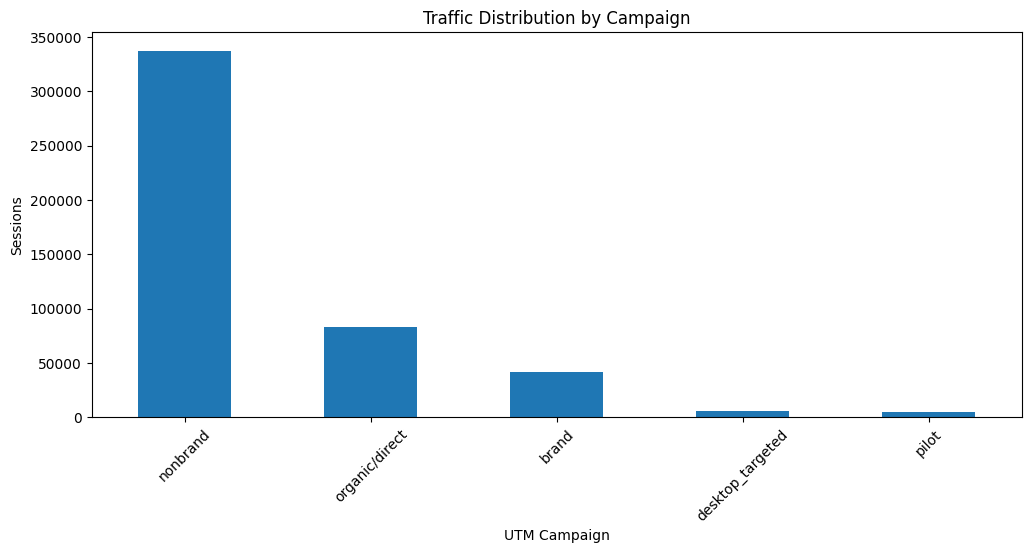

In [31]:
campaign_dist.plot(kind='bar', figsize=(12,5))
plt.title('Traffic Distribution by Campaign')
plt.xlabel('UTM Campaign')
plt.ylabel('Sessions')
plt.xticks(rotation=45)
plt.show()

6. Product Sales Distribution

In [34]:
product_sales = (order_product['product_name'].value_counts())

In [35]:
product_sales

product_name
The Original Mr. Fuzzy        24226
The Forever Love Bear          5796
The Hudson River Mini bear     5018
The Birthday Sugar Panda       4985
Name: count, dtype: int64

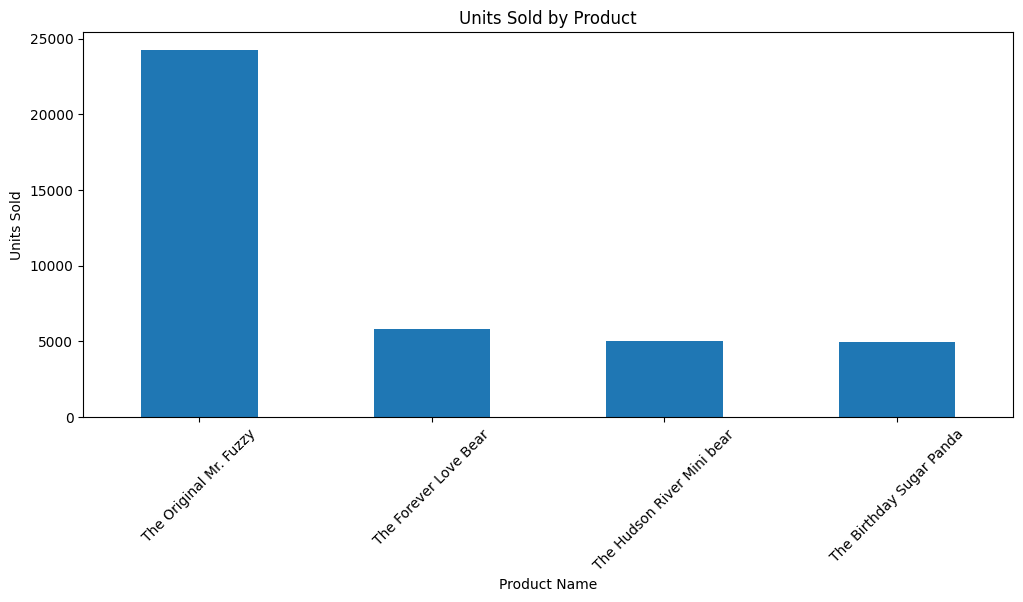

In [36]:
product_sales.plot(kind='bar', figsize=(12,5))
plt.title('Units Sold by Product')
plt.xlabel('Product Name')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.show()

7. Order Revenue Distribution

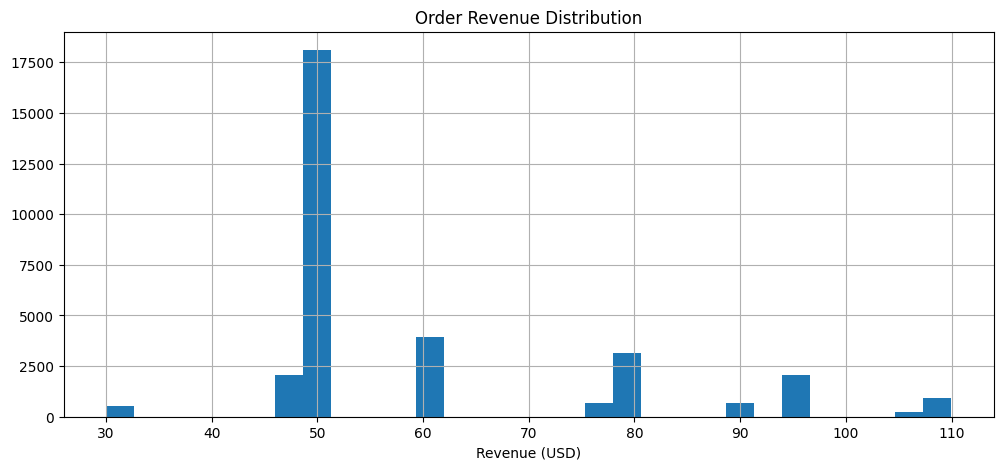

In [41]:
session_order['price_usd'].dropna().hist(bins=30, figsize=(12,5))
plt.title('Order Revenue Distribution')
plt.xlabel('Revenue (USD)')
plt.show()

8. Refund Amount Distribution

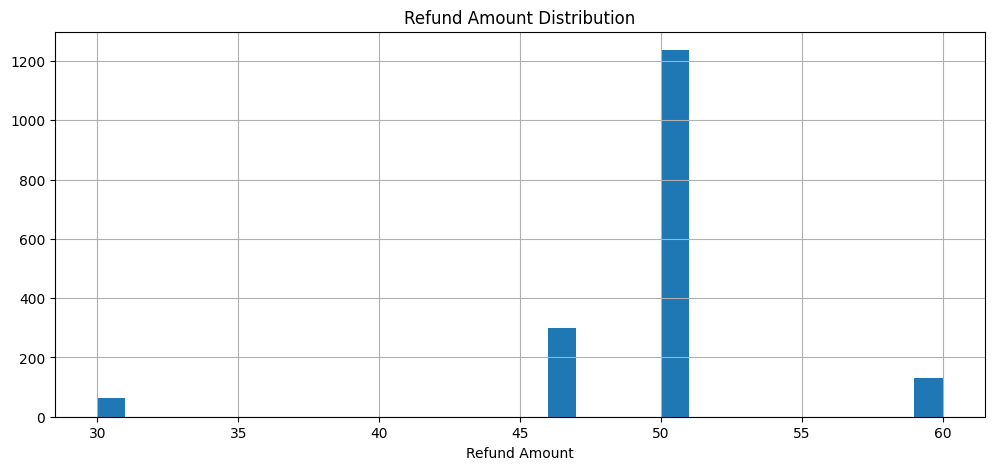

In [43]:
order_refund['refund_amount_usd'].dropna().hist(bins=30, figsize=(12,5))

plt.title('Refund Amount Distribution')
plt.xlabel('Refund Amount')
plt.show()

9. Top Refunded Products

In [44]:
refund_product = (
    order_product
    .merge(
        order_refund[
            [
                'order_item_id',
                'refund_amount_usd'
            ]
        ],
        on='order_item_id',
        how='left'
    )
)

In [45]:
refund_count = (
    refund_product[
        refund_product[
            'refund_amount_usd'
        ].notna()
    ]
    ['product_name']
    .value_counts()
)

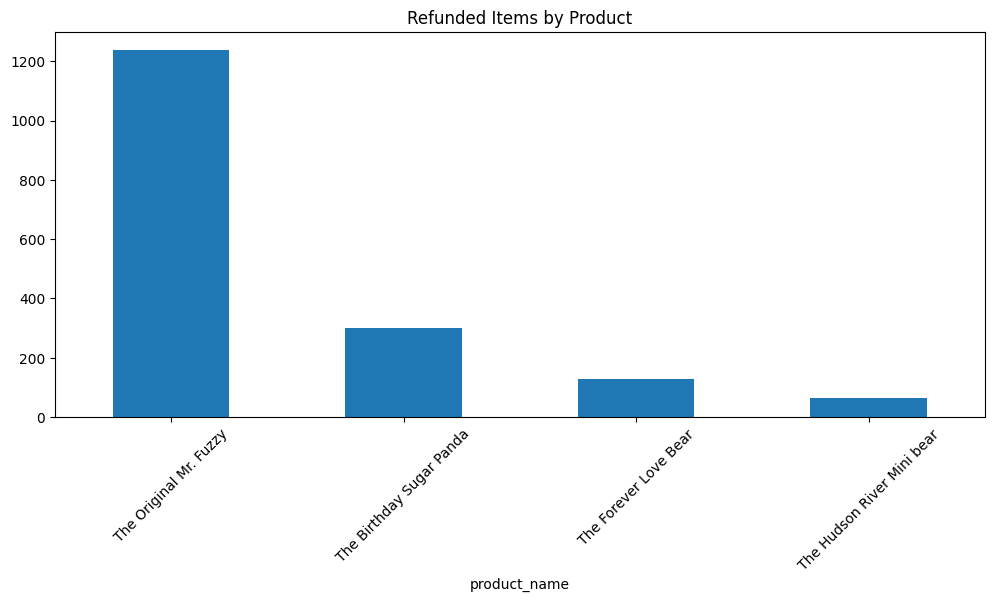

In [47]:
refund_count.plot(kind='bar', figsize=(12,5))

plt.title('Refunded Items by Product')
plt.xticks(rotation=45)
plt.show()

Key Findings

1. Website traffic showed a sustained upward trend over the observation period, despite short-term fluctuations.

2. gsearch remains the dominant traffic source.

3. Desktop users account for the majority of sessions.

4. Nonbrand is the most frequently used marketing campaign.

5. The Original Mr. Fuzzy is the best-selling product.

6. Order revenue is concentrated around several distinct price points, corresponding to the website's product pricing.

7. Refunds are concentrated in a small number of products, led by The Original Mr. Fuzzy.

8. The refund amount distribution shows no significant outliers or unusual patterns.